## Optimizing an airfoil using AeroSandbox to verify results of the NN-Multifidelity-GP

In [1]:
import aerosandbox as asb
import aerosandbox.numpy as np
import matplotlib.pyplot as plt
import aerosandbox.tools.pretty_plots as p


c:\ProgramData\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [ ]:
#guessing the right Kulfan parameters

#"NACA 4308"
naca_4308 = asb.KulfanAirfoil("naca4308")
naca_4308.__getstate__()

{'name': 'naca4308',
 'lower_weights': array([-0.12307313, -0.08104528,  0.1283143 , -0.1526097 ,  0.12292324,
        -0.0517895 ,  0.03994848,  0.01316177]),
 'upper_weights': array([0.11420502, 0.12344032, 0.3505256 , 0.02885758, 0.33380685,
        0.12194473, 0.23314759, 0.2004762 ]),
 'leading_edge_weight': np.float64(0.275730442950163),
 'TE_thickness': np.float64(0.0017059909161978755),
 'N1': 0.5,
 'N2': 1.0}

In [ ]:
#"NACA 8312"
naca_8312 = asb.KulfanAirfoil("naca8312")
naca_8312.__getstate__()


[-0.18854811 -0.09598399  0.29535468 -0.25482703  0.28485097 -0.05573907
  0.12034849  0.07144925]


In [91]:
lower_weights_min = np.min(np.concatenate([naca_4308.lower_weights, naca_8312.lower_weights]))
lower_weights_max = np.max(np.concatenate([naca_4308.lower_weights, naca_8312.lower_weights]))

upper_weights_min = np.min(np.concatenate([naca_4308.upper_weights, naca_8312.upper_weights]))
upper_weights_max = np.max(np.concatenate([naca_4308.upper_weights, naca_8312.upper_weights]))

leading_edge_min  = np.min([naca_4308.leading_edge_weight, naca_8312.leading_edge_weight])
leading_edge_max  = np.max([naca_4308.leading_edge_weight, naca_8312.leading_edge_weight])

In [94]:
Re = 5e5
mach = 0.0

initial_guess_airfoil = asb.KulfanAirfoil("naca0012")
initial_guess_airfoil_name = "Initial Guess (NACA0012)"

opti = asb.Opti()

optimized_airfoil = asb.KulfanAirfoil(
    name = "Optimized",
    lower_weights = opti.variable(
        init_guess = initial_guess_airfoil.lower_weights,
        lower_bound = lower_weights_min,
        upper_bound = lower_weights_max
    ),
    upper_weights = opti.variable(
            init_guess = initial_guess_airfoil.upper_weights,
            lower_bound = upper_weights_min,
            upper_bound = upper_weights_max
    ),
    leading_edge_weight = opti.variable(
                init_guess = initial_guess_airfoil.leading_edge_weight,
                lower_bound = leading_edge_min,
                upper_bound = leading_edge_max
    ),
    TE_thickness = 0.0,
)

alpha = opti.variable(
    init_guess = 5,
    upper_bound = 10,
    lower_bound = 0
)


aero = optimized_airfoil.get_aero_from_neuralfoil(
    alpha = alpha,
    Re = Re,
    mach = mach,
    n_crit=1,
    xtr_upper=0.1,
    xtr_lower=0.1
)

target_CL = 1.0
opti.subject_to([
    aero["analysis_confidence"] > 0.90,
    aero["CL"] == 1.0,
    optimized_airfoil.local_thickness() <= 0.12,
    #optimized_airfoil.local_thickness(x_over_c=0.90) >= 0.0,
    optimized_airfoil.lower_weights[0] < -0.05,
    optimized_airfoil.upper_weights[0] >  0.05,
    optimized_airfoil.local_thickness() > 0,
    optimized_airfoil.TE_angle() >= 6.03
])

def get_wiggliness(af):
    return sum([
        np.sum(np.diff(array)**2)
        for array in [af.lower_weights, af.upper_weights]
    ])
opti.subject_to(
    get_wiggliness(optimized_airfoil) < 2 * get_wiggliness(initial_guess_airfoil)
)

opti.minimize((aero["CD"]))


sol = opti.solve(
    behavior_on_failure = "return_last",
    options = {"ipopt.mu_strategy" : "monotone", "ipopt.start_with_resto": "yes"},
)

optimized_airfoil = sol(optimized_airfoil)
aero = sol(aero)

c:\ProgramData\anaconda3\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)


This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:       18
Number of nonzeros in inequality constraint Jacobian.:     3508
Number of nonzeros in Lagrangian Hessian.............:      171

Total number of variables............................:       18
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:      243
        inequality constraints with only lower bounds:      122
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:      121

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.3490093e-02 5.18e+17 9.79e-01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

c:\ProgramData\anaconda3\Lib\site-packages\aerosandbox\optimization\opti.py:920: UserWarning: Optimization failed. Returning last solution.
  warnings.warn("Optimization failed. Returning last solution.")


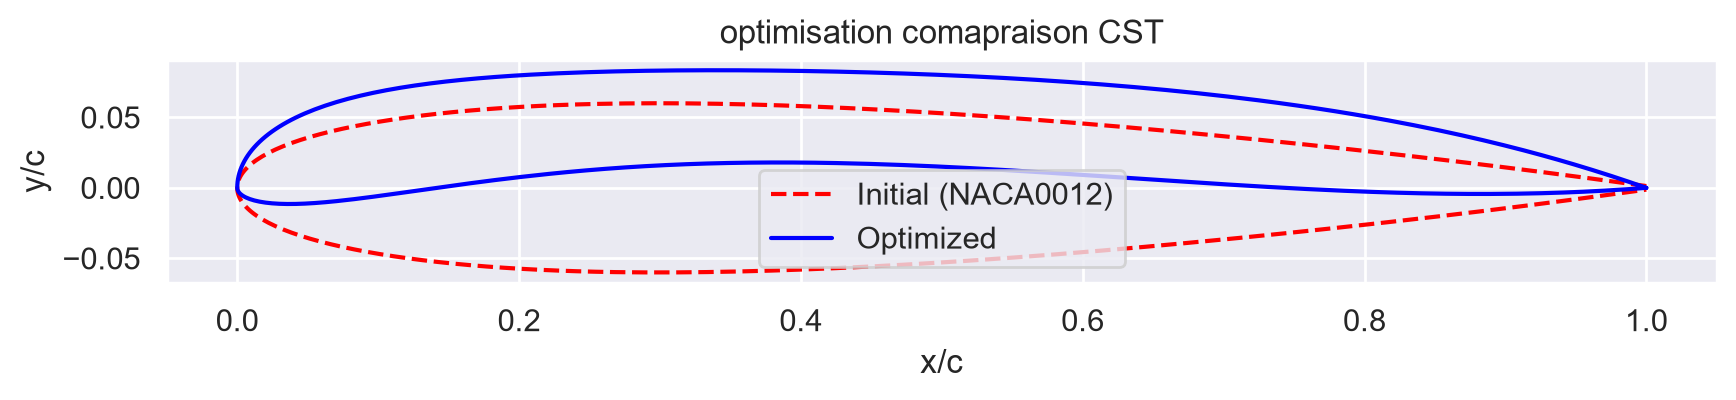

In [95]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    initial_guess_airfoil.x(), 
    initial_guess_airfoil.y(), 
    'r--', 
    label="Initial (NACA0012)"
)
ax.plot(
    optimized_airfoil.x(), 
    optimized_airfoil.y(), 
    'b-', 
    label="Optimized"
)


ax.set_aspect('equal', adjustable='box')
ax.legend()
ax.grid(True)
ax.set_xlabel("x/c")
ax.set_ylabel("y/c")
ax.set_title("optimisation comapraison CST")
plt.show()


coordinates = optimized_airfoil.coordinates